<a href="https://colab.research.google.com/github/pranjalcodera30/Predictive-Maintenance-for-Industrial-Equipment/blob/main/Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install any extra libraries if needed
# !pip install shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')


All libraries loaded successfully.


In [3]:
telemetry   = pd.read_csv('PdM_telemetry.csv',  parse_dates=['datetime'])
failures    = pd.read_csv('PdM_failures.csv',    parse_dates=['datetime'])
maintenance = pd.read_csv('PdM_maint.csv',       parse_dates=['datetime'])
machines    = pd.read_csv('PdM_machines.csv')
errors      = pd.read_csv('PdM_errors.csv',      parse_dates=['datetime'])

print('Shapes:')
for name, df in [('Telemetry', telemetry), ('Failures', failures),
                 ('Maintenance', maintenance), ('Machines', machines), ('Errors', errors)]:
    print(f'  {name:12s}: {df.shape}')

print('\nTelemetry sample:')
telemetry.head()

Shapes:
  Telemetry   : (876100, 6)
  Failures    : (761, 3)
  Maintenance : (3286, 3)
  Machines    : (100, 3)
  Errors      : (3919, 3)

Telemetry sample:


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [4]:
# Check missing values and basic stats
print('=== Missing Values ===')
print(telemetry.isnull().sum())

print('\n=== Sensor Stats ===')
print(telemetry[['volt','rotate','pressure','vibration']].describe().round(2))

print('\n=== Date Range ===')
print('From:', telemetry['datetime'].min())
print('To:  ', telemetry['datetime'].max())

print('\n=== Unique Machines ===')
print(telemetry['machineID'].nunique(), 'machines')

print('\n=== Failure Types ===')
print(failures['failure'].value_counts())

=== Missing Values ===
datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

=== Sensor Stats ===
            volt     rotate   pressure  vibration
count  876100.00  876100.00  876100.00  876100.00
mean      170.78     446.61     100.86      40.39
std        15.51      52.67      11.05       5.37
min        97.33     138.43      51.24      14.88
25%       160.30     412.31      93.50      36.78
50%       170.61     447.56     100.43      40.24
75%       181.00     482.18     107.56      43.78
max       255.12     695.02     185.95      76.79

=== Date Range ===
From: 2015-01-01 06:00:00
To:   2016-01-01 06:00:00

=== Unique Machines ===
100 machines

=== Failure Types ===
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64


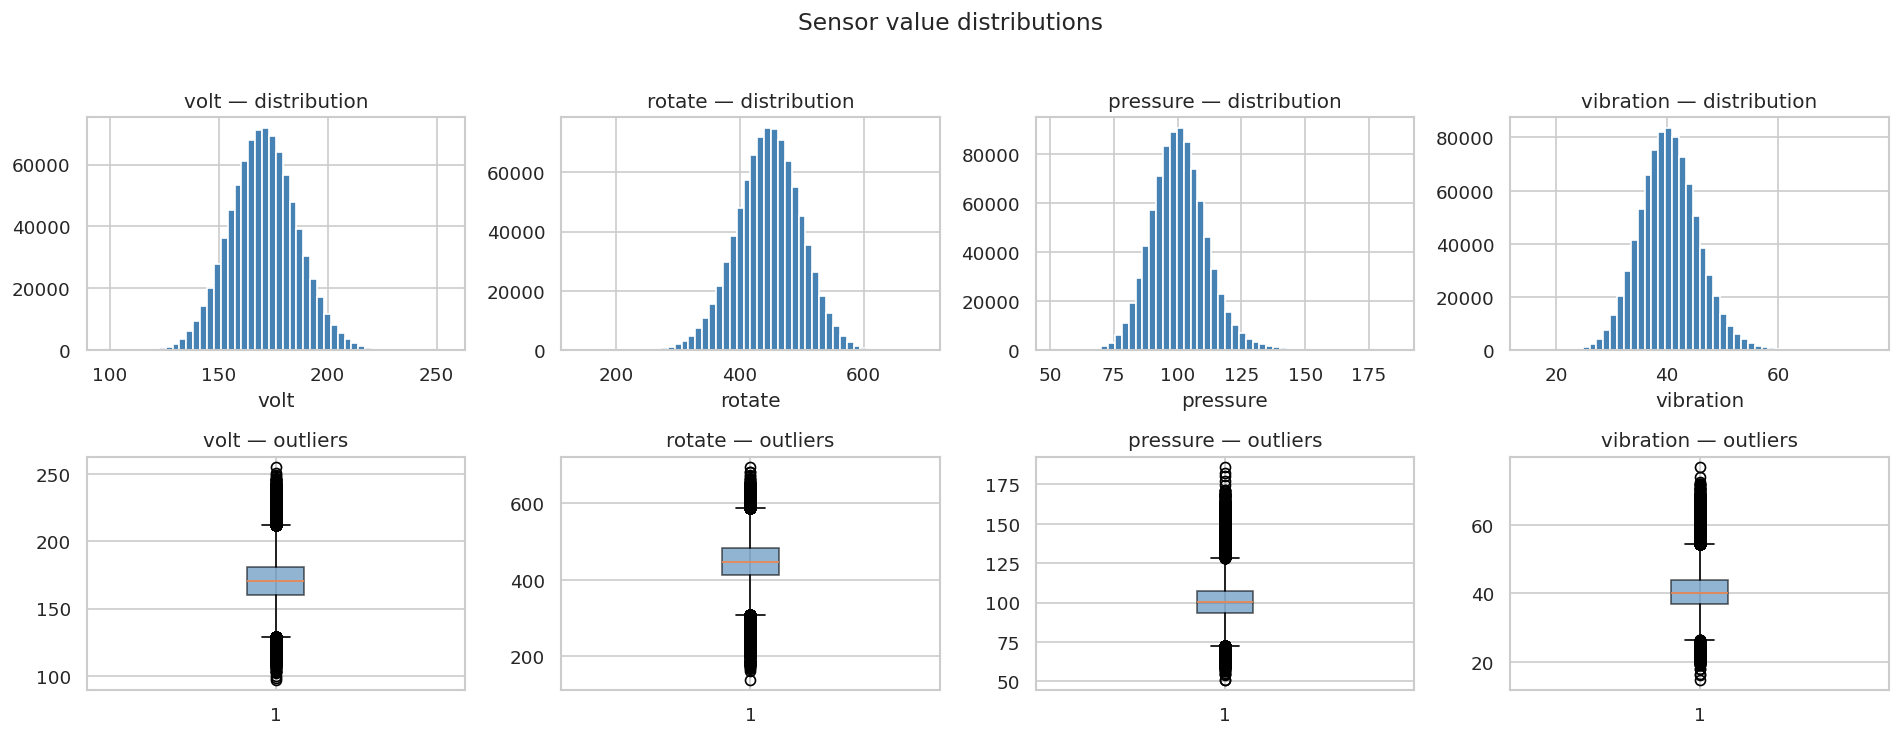

In [5]:
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, col in enumerate(sensor_cols):
    # Histogram
    axes[0, i].hist(telemetry[col], bins=50, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — distribution')
    axes[0, i].set_xlabel(col)

    # Box plot
    axes[1, i].boxplot(telemetry[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'{col} — outliers')

plt.suptitle('Sensor value distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

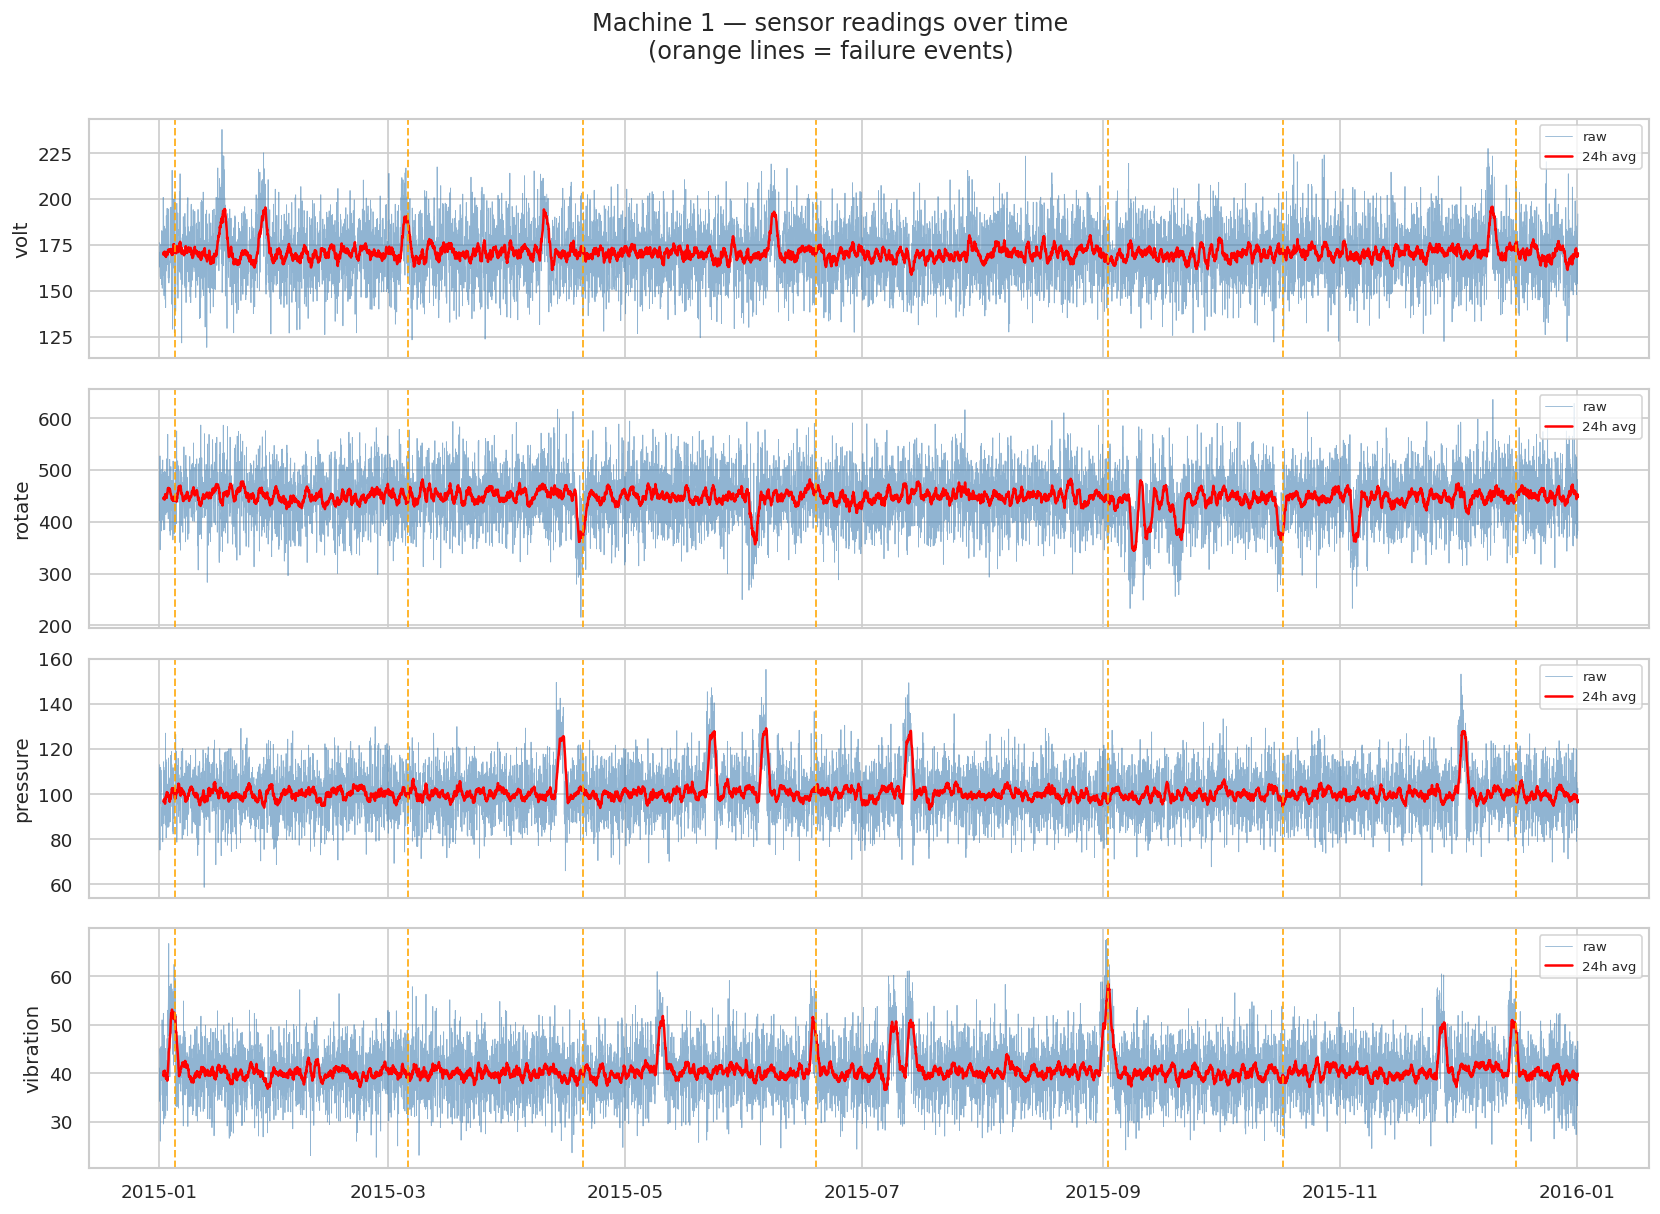


Machine 1 had 7 failures:
             datetime failure
0 2015-01-05 06:00:00   comp4
1 2015-03-06 06:00:00   comp1
2 2015-04-20 06:00:00   comp2
3 2015-06-19 06:00:00   comp4
4 2015-09-02 06:00:00   comp4
5 2015-10-17 06:00:00   comp2
6 2015-12-16 06:00:00   comp4


In [6]:
# Look at machine 1's sensor readings over the full year
machine_sample = telemetry[telemetry['machineID'] == 1].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, sensor_cols):
    ax.plot(machine_sample['datetime'], machine_sample[col],
            linewidth=0.5, alpha=0.6, color='steelblue', label='raw')
    ax.plot(machine_sample['datetime'],
            machine_sample[col].rolling(24).mean(),
            linewidth=1.5, color='red', label='24h avg')
    ax.set_ylabel(col)
    ax.legend(loc='upper right', fontsize=8)

# Mark failure events for machine 1
machine_failures = failures[failures['machineID'] == 1]
for _, row in machine_failures.iterrows():
    for ax in axes:
        ax.axvline(row['datetime'], color='orange', linewidth=1.2,
                   linestyle='--', alpha=0.8)

plt.suptitle('Machine 1 — sensor readings over time\n(orange lines = failure events)', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nMachine 1 had {len(machine_failures)} failures:')
print(machine_failures[['datetime','failure']])

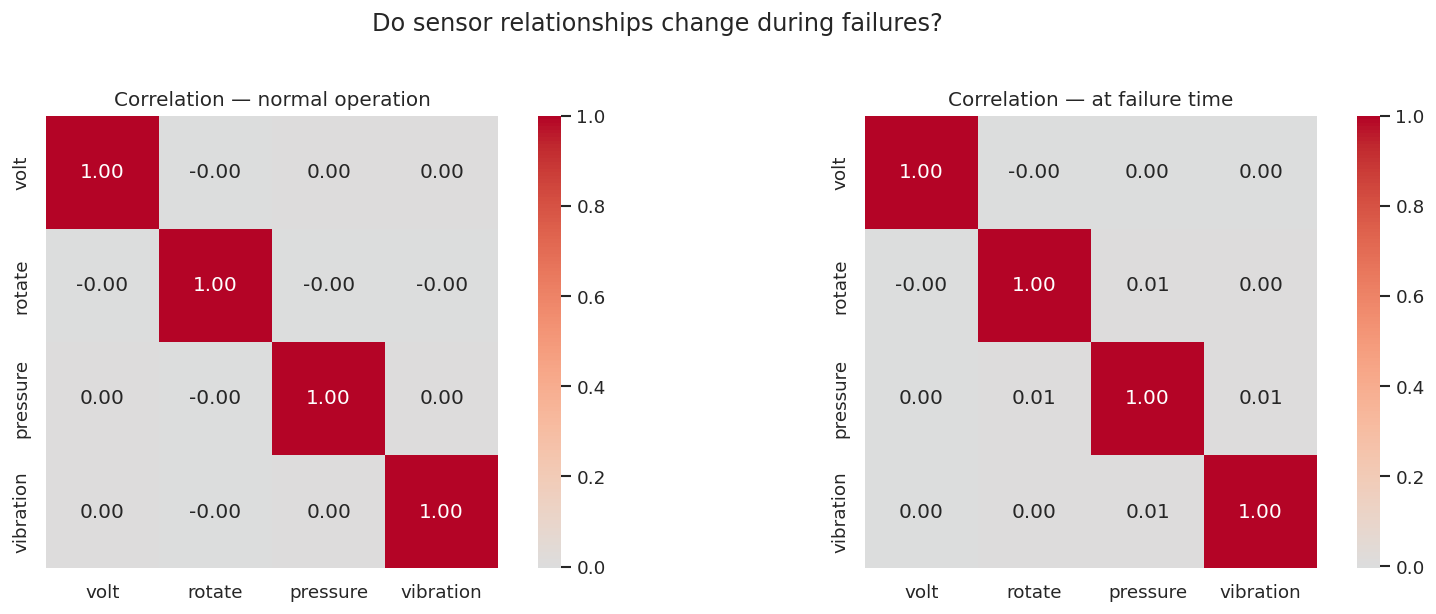

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal readings (no failure in next 24h)
failure_times = set(failures['datetime'])
normal = telemetry[~telemetry['datetime'].isin(failure_times)]
failure_rows = telemetry[telemetry['datetime'].isin(failure_times)]

sns.heatmap(normal[sensor_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0], square=True)
axes[0].set_title('Correlation — normal operation')

sns.heatmap(failure_rows[sensor_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1], square=True)
axes[1].set_title('Correlation — at failure time')

plt.suptitle('Do sensor relationships change during failures?', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Merge machine info and sort
df = telemetry.merge(machines, on='machineID', how='left')
df = df.sort_values(['machineID', 'datetime']).reset_index(drop=True)

# Create failure label: 1 if failure occurs within next 24h
WINDOW = 24
df['label'] = 0

for _, row in failures.iterrows():
    window_start = row['datetime'] - pd.Timedelta(hours=WINDOW)
    mask = (
        (df['machineID'] == row['machineID']) &
        (df['datetime'] >= window_start) &
        (df['datetime'] < row['datetime'])
    )
    df.loc[mask, 'label'] = 1

print('Label distribution:')
print(df['label'].value_counts())
print(f'\nFailure rate: {df["label"].mean():.3%}')

Label distribution:
label
0    858916
1     17184
Name: count, dtype: int64

Failure rate: 1.961%


In [9]:
# Rolling statistics (captures trends leading up to failure)
for col in sensor_cols:
    for window in [3, 12, 24]:
        grp = df.groupby('machineID')[col]
        df[f'{col}_mean_{window}h'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{col}_std_{window}h'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))

# Lag features (what was the sensor reading X hours ago)
for col in sensor_cols:
    for lag in [1, 3, 6]:
        df[f'{col}_lag{lag}'] = df.groupby('machineID')[col].shift(lag)

# Time features
df['hour']      = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek

# Encode 'model' column (text → number)
df['model'] = LabelEncoder().fit_transform(df['model'].astype(str))

# Drop NaN rows created by lag features
df.dropna(inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'Total features created: {df.shape[1] - 4}')  # minus datetime, machineID, label, age
print(f'\nSample of new feature names:')
new_cols = [c for c in df.columns if any(x in c for x in ['mean','std','lag'])]
print(new_cols[:10])

Dataset shape: (875500, 47)
Total features created: 43

Sample of new feature names:
['volt_mean_3h', 'volt_std_3h', 'volt_mean_12h', 'volt_std_12h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_3h', 'rotate_std_3h', 'rotate_mean_12h', 'rotate_std_12h']


In [10]:
# Time-based split (never shuffle time-series data!)
split_date = pd.Timestamp('2015-10-01')

feature_cols = [c for c in df.columns if c not in
                ['datetime', 'machineID', 'label']]

train = df[df['datetime'] <= split_date]
test  = df[df['datetime'] >  split_date]

X_train, y_train = train[feature_cols], train['label']
X_test,  y_test  = test[feature_cols],  test['label']

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train failure rate: {y_train.mean():.3%}')
print(f'Test failure rate:  {y_test.mean():.3%}')

# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('\nTraining... (may take 1-2 minutes)')
rf.fit(X_train, y_train)
print('Done!')

Train: (654100, 44)  |  Test: (221400, 44)
Train failure rate: 1.991%
Test failure rate:  1.828%

Training... (may take 1-2 minutes)
Done!


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    217353
     Failure       0.24      0.93      0.38      4047

    accuracy                           0.94    221400
   macro avg       0.62      0.94      0.67    221400
weighted avg       0.98      0.94      0.96    221400

ROC-AUC Score: 0.9710


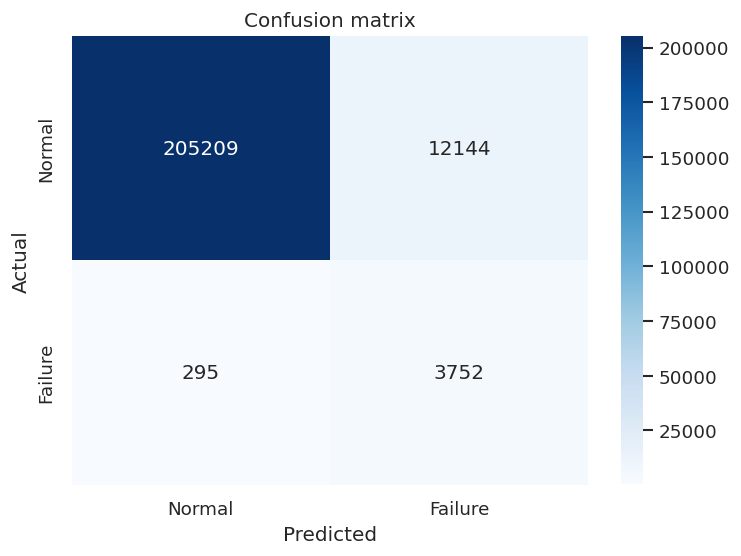

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

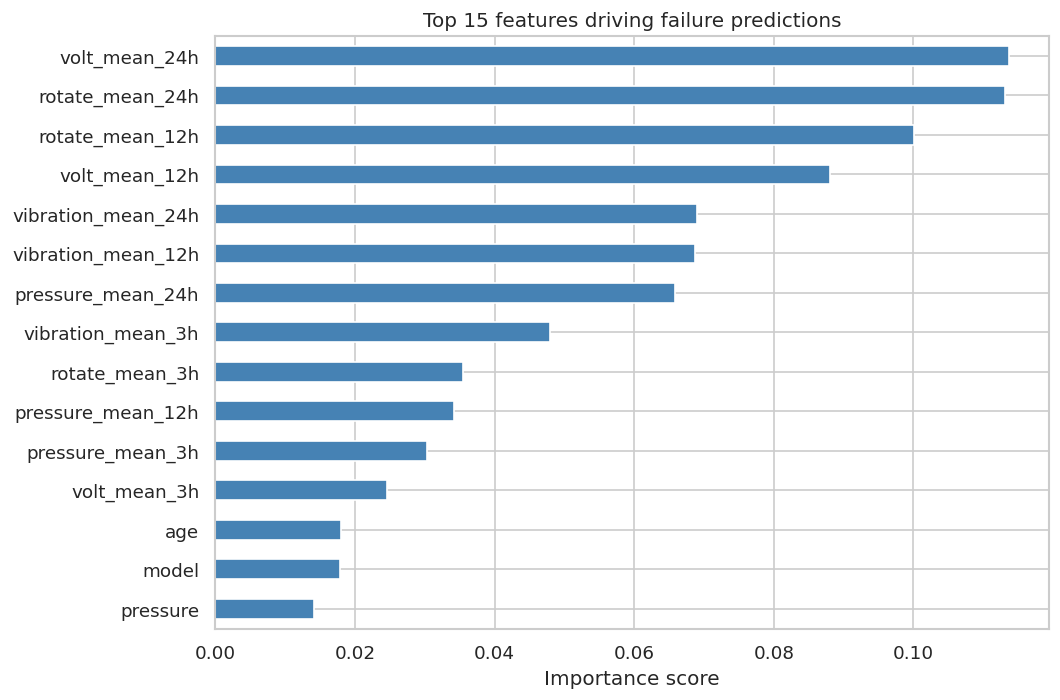

=== TOP 3 FEATURES ===
1. volt_mean_24h: 0.1137
2. rotate_mean_24h: 0.1131
3. rotate_mean_12h: 0.1000


In [12]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15).sort_values()

top15.plot(kind='barh', figsize=(9, 6), color='steelblue', edgecolor='white')
plt.xlabel('Importance score')
plt.title('Top 15 features driving failure predictions')
plt.tight_layout()
plt.show()

print('=== TOP 3 FEATURES ===')
for i, (feat, score) in enumerate(importances.nlargest(3).items(), 1):
    print(f'{i}. {feat}: {score:.4f}')

=== Maintenance Priority List (Top 10 Machines) ===
           avg_risk  high_risk_hours
machineID                           
94            13.13              309
23            11.94              280
13            11.59              275
85            11.25              265
37            11.24              263
99            10.87              269
63            10.85              228
78            10.73              257
70            10.60              249
56            10.59              262


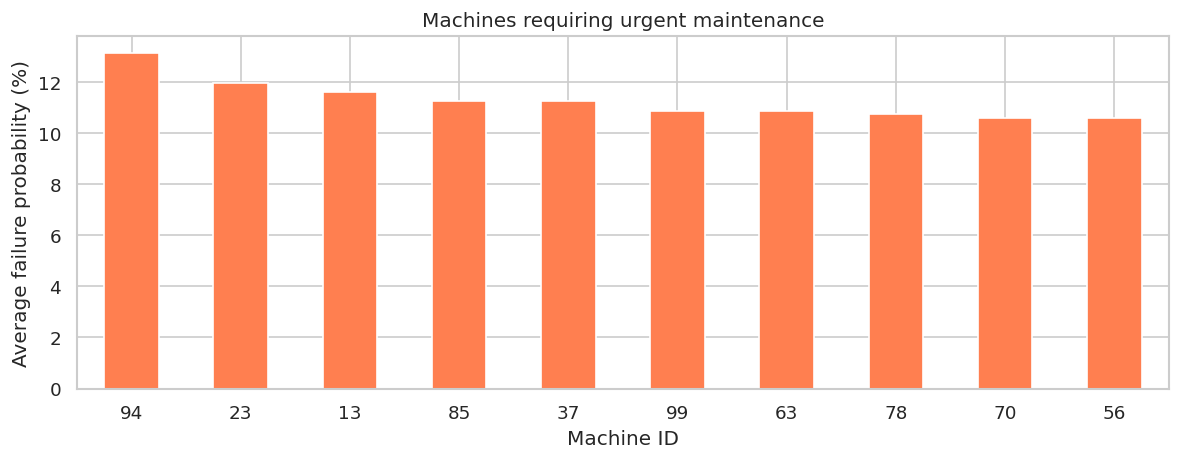

In [13]:
test_copy = test.copy()
test_copy['failure_prob'] = y_prob

risk = (
    test_copy.groupby('machineID')
    .agg(avg_risk=('failure_prob', 'mean'),
         high_risk_hours=('failure_prob', lambda x: (x >= 0.5).sum()))
    .sort_values('avg_risk', ascending=False)
    .head(10)
)

risk['avg_risk'] = (risk['avg_risk'] * 100).round(2)
print('=== Maintenance Priority List (Top 10 Machines) ===')
print(risk.to_string())

risk['avg_risk'].plot(kind='bar', color='coral', edgecolor='white', figsize=(10,4))
plt.ylabel('Average failure probability (%)')
plt.xlabel('Machine ID')
plt.title('Machines requiring urgent maintenance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
import urllib.request
# (app.py is already in your Colab session if you uploaded it,
#  otherwise paste the downloaded app.py contents)

# Launch with a public URL
from pyngrok import ngrok
import subprocess, threading

def run():
    subprocess.run(['streamlit', 'run', 'app.py',
                    '--server.port=8501', '--server.headless=true'])

threading.Thread(target=run, daemon=True).start()

# You need to replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken.
# Get it from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3ECzfETUHxdLC9FFqQTQfkKokhG_6AjxLaTVuGKwThaNBZL1M') # <-- Replace 'YOUR_AUTHTOKEN' with your actual token here!

import time; time.sleep(4)
url = ngrok.connect(8501)
print("Your app is live at:", url)

Your app is live at: NgrokTunnel: "https://unfiled-undying-purity.ngrok-free.dev" -> "http://localhost:8501"
